In [574]:
print("Hello, World")

Hello, World


In [575]:
!pip install numpy

In [576]:
!pip install matplotlib

In [577]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [578]:
def f(x):
    return 3*x**2 -4*x + 5

In [579]:
f(3)

20

[-5.   -4.75 -4.5  -4.25 -4.   -3.75 -3.5  -3.25 -3.   -2.75 -2.5  -2.25
 -2.   -1.75 -1.5  -1.25 -1.   -0.75 -0.5  -0.25  0.    0.25  0.5   0.75
  1.    1.25  1.5   1.75  2.    2.25  2.5   2.75  3.    3.25  3.5   3.75
  4.    4.25  4.5   4.75]


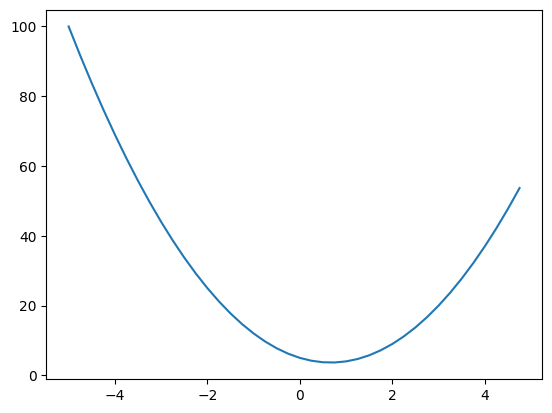

In [580]:
xs = np.arange(-5, 5, 0.25)
print(xs)
ys = f(xs)
plt.plot(xs, ys)

In [581]:
class Value:
    def __init__(self, data, _children = (), _op='', label=''):
        self.data = data
        self.grad=0.0
        self._backward = lambda:None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward

        return out
    
    def __radd__(self, other):
        return self+other
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad # chain rule
            other.grad += self.data * out.grad  # chain rule
        out._backward = _backward

        return out
    
    def __rmul__(self, other):
        return self*other
    
    def __truediv__(self, other):
        return self * other ** -1
    
    def __pow__(self, other):
        assert isinstance(other, (int, float)) # only supporting int/float powers for now

        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other -1)) * out.grad
        out._backward = _backward

        return out
    
    def __sub__(self, other):
        return self + (-other)
    
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t, (self, ), "tanh")

        def _backward():
            self.grad += (1 - t**2) * out.grad # chain rule
        out._backward = _backward

        return out
    
    def exp(self):
        x=self.data
        out = Value(math.exp(x), (self, ), "exp")

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
    
        return out

    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()
        
        


    
a=Value(3, label="a")
b=Value(4, label="b")
c=Value(8, label="c")
e=a*b;e.label="e"
d=e+c;d.label="d"
f=Value(-2, label="f")
L = d*f; L.label="L"

In [582]:
d._op

'+'

In [583]:
!pip install graphviz

In [584]:
!pip install python-graphviz

ERROR: Could not find a version that satisfies the requirement python-graphviz (from versions: none)
ERROR: No matching distribution found for python-graphviz


In [585]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg'):
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': 'LR'}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [586]:
L.grad = 1
d.grad = -2
f.grad = 20
c.grad = -2 
e.grad = -2
a.grad = -8
b.grad = -6

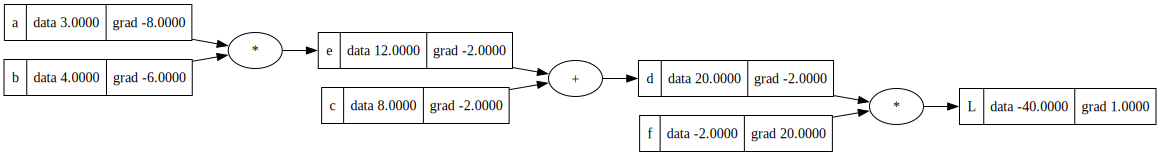

In [587]:
draw_dot(L)

In [588]:
def lol():
    
    h = 0.0001
    
    a=Value(3, label="a")
    b=Value(4, label="b")
    c=Value(8, label="c")
    e=a*b;e.label="e"
    d=e+c;d.label="d"
    f=Value(-2, label="f")
    L = d*f; L.label="L"
    L1 = L.data

    a=Value(3, label="a")
    b=Value(4+h, label="b")
    c=Value(8, label="c")
    e=a*b;e.label="e"
    d=e+c;d.label="d"
    f=Value(-2, label="f")
    L = d*f; L.label="L"
    L2 = L.data

    print((L2 - L1)/h)

lol()


-5.9999999999860165


In [589]:
# Input Values
x1 = Value(2, label="x1")
x2 = Value(0, label="x2")

# Weights
w1 = Value(-3, label="w1")
w2 = Value(1, label="w2")

# Bias
b = Value(6.8813735870195432, label="b")

# Calculate x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label="x1w1"
x2w2 = x2*w2; x2w2.label="x2w2"

x1w1plusx2w2 = x1w1 + x2w2; x1w1plusx2w2.label="x1w1plusx2w2"

# Final neuron 
n = x1w1plusx2w2+b; n.label="n"

o = n.tanh();o.label="o"




In [590]:
# # Grad here
# o.grad=1
# n.grad=0.5
# b.grad = 0.5
# x1w1plusx2w2.grad = 0.5
# x1w1.grad = 0.5
# x2w2.grad=0.5
# x2.grad = 0.5
# w2.grad=0
# w1.grad = 1
# x1.grad = -1.5

In [591]:
# Manual backpropagation
# o.grad = 1.0
# o._backward()
# n._backward()
# x1w1plusx2w2._backward()
# x1w1._backward()
# x2w2._backward()



In [592]:
# Automatic backpropagation using topological sort
o.backward()
    

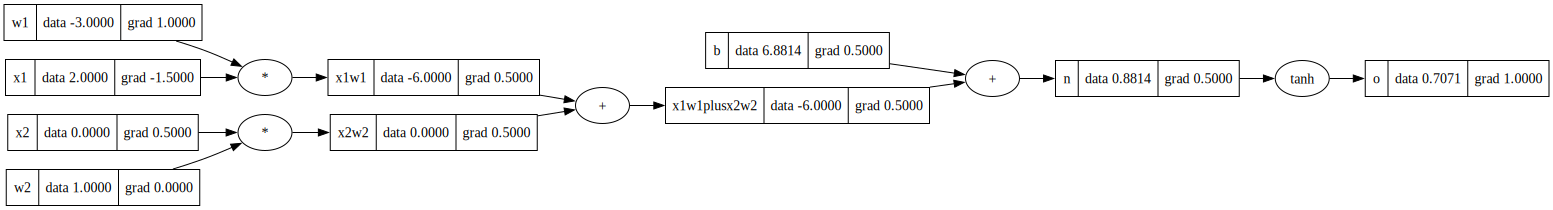

In [593]:
draw_dot(o)

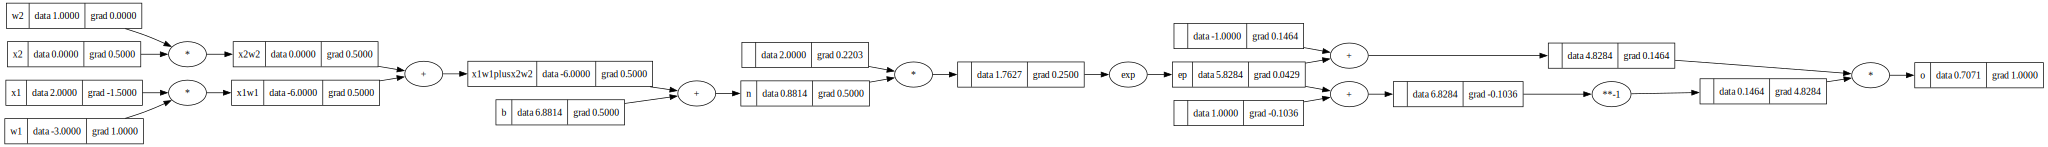

In [594]:
# Input Values
x1 = Value(2, label="x1")
x2 = Value(0, label="x2")

# Weights
w1 = Value(-3, label="w1")
w2 = Value(1, label="w2")

# Bias
b = Value(6.8813735870195432, label="b")

# Calculate x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label="x1w1"
x2w2 = x2*w2; x2w2.label="x2w2"

x1w1plusx2w2 = x1w1 + x2w2; x1w1plusx2w2.label="x1w1plusx2w2"

# Final neuron 
n = x1w1plusx2w2+b; n.label="n"

# Breaking down tanh into exponential equation format
ep = (2*n).exp()
ep.label="ep"
o = (ep-1)/(ep+1)
o.label = "o"
o.backward()
draw_dot(o)


### Micrograd kinda operations but in PyTorch

In [595]:
!pip install torch torchvision torchaudio

In [596]:
import torch
x1=torch.Tensor([2.0]).double();x1.requires_grad=True
w1=torch.Tensor([-3.0]).double();w1.requires_grad=True
x2=torch.Tensor([0.0]).double();x2.requires_grad=True
w2=torch.Tensor([1.0]).double();w2.requires_grad=True
b=torch.Tensor([6.8813735870195432]).double();b.requires_grad=True
n=w1*x1 + w2*x2 + b
o=torch.tanh(n)

print(o.data.item())
o.backward()

print("-------")
print(f'x1={x1.grad.item()}')
print(f'w1={w1.grad.item()}')
print(f'x2={x2.grad.item()}')
print(f'w2={w2.grad.item()}')


0.7071066904050358
-------
x1=-1.5000003851533106
w1=1.0000002567688737
x2=0.5000001283844369
w2=0.0


In [597]:
import random
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        a = self.b
        for wi, xi in zip(self.w, x):
            a += wi*xi
        out = a.tanh()
        return out
    
    def parameters(self):
        return self.w + [self.b]
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params
    
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin]+nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x=layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    

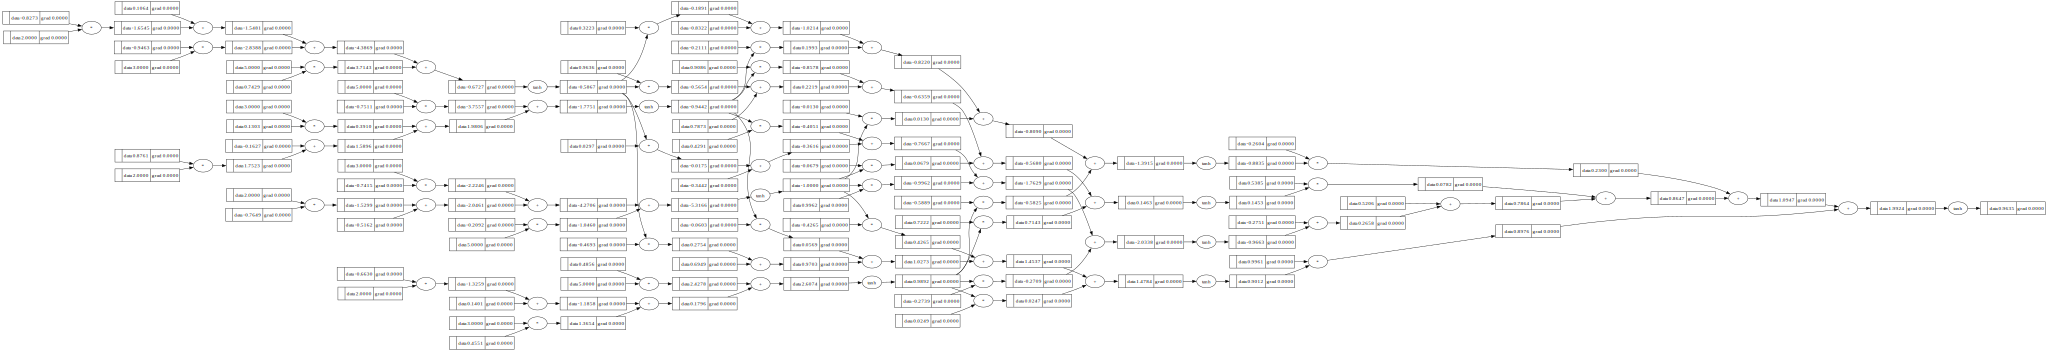

In [598]:
x=[2,3, 5]
n=MLP(3, [4, 4, 1])
n(x)
draw_dot(n(x))

In [599]:
xs = [
    [2, 3, 5],
    [-1, 3, 6],
    [-2, 4, 1], 
    [9, -8, -1],
]

ys = [1, -1, -1, 1]


In [600]:
# Mean squared sum of losses
ypred = [n(x) for x in xs]
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.7001170744705725)

In [601]:
loss.backward()

In [602]:
for p in n.parameters():
    p.data += -0.01*p.grad

In [603]:
ypred

[Value(data=0.9634831136081567),
 Value(data=0.9701828205587738),
 Value(data=0.9532586808681487),
 Value(data=0.9559117853943662)]

In [682]:
for k in range(10):
    ypred = [n(x) for x in xs]
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad = 0.0

    loss.backward()

    for p in n.parameters():
        p.data += -0.01*p.grad
    
    print(k, loss.data)

0 0.010494513087432666
1 0.010466340046769312
2 0.01043830276906026
3 0.010410400324993706
4 0.010382631793458745
5 0.010354996261456986
6 0.010327492824015017
7 0.010300120584098528
8 0.01027287865252688
9 0.01024576614788939


In [683]:
ypred

[Value(data=0.9256342899325514),
 Value(data=-0.944171012246774),
 Value(data=-0.961728699496075),
 Value(data=0.9884267982717845)]